# Online Review Sentiment Analysis (Online Store/Social Commerce)
### NLP & Sentiment Analysis 
### Name: MD. Shafiqul Islam, ID: 905253024

This notebook will do the followings:
1. Load the dataset
2. Text preprocessing (tokenization, stopword removal, TF-IDF)
3. Train/test split
4. Build and evaluate classification models
5. Compare models
6. Visualize sentiment trends

All data here is **synthetic**, generated for project purposes.

In [2]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'DejaVu Serif'
print("Libraries ready.")

Libraries ready.


## 1. Load the dataset

In [4]:
df = pd.read_csv('synthetic_online_reviews_sentiment_1200.csv', parse_dates=['date'])
print(df.shape)
df.head()

(1200, 9)


,review_id,review_text,product,category,sentiment,source,date,rating,verified_purchase
0,REV0350,The size and appearance are as expected. I hav...,Wireless Earbuds,Electronics,neutral,Social Commerce,2026-01-03,3,Yes
1,REV1126,I expected better quality. The frame quality i...,Sunglasses,Fashion,negative,Online Store,2025-08-24,2,Yes
2,REV0039,"It does what it is supposed to do, although th...",Laptop Stand,Electronics,neutral,Social Commerce,2026-03-30,4,Yes
3,REV0374,"The bluetooth speaker is not bad, but I would ...",Bluetooth Speaker,Electronics,neutral,Online Store,2025-12-14,3,Yes
4,REV0778,Really happy with this purchase. The switch wo...,Desk Lamp,Home & Kitchen,positive,Online Store,2026-03-16,5,Yes


In [5]:
print(df['sentiment'].value_counts())
print()
print(df['source'].value_counts())

sentiment
positive    540
negative    360
neutral     300
Name: count, dtype: int64

source
Online Store       620
Social Commerce    580
Name: count, dtype: int64


## 2. Text preprocessing

Three standard steps before modeling:
- **Tokenization** — split text into individual words
- **Stopword removal** — drop common words that carry little meaning ("the", "is", "and"...)
- **TF-IDF** — turn cleaned text into numeric features that weigh rare, informative words more heavily than common ones

In [6]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#', '', text)          # remove URLs, mentions, hashtag symbol
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['review_text'].apply(clean_text)
df[['review_text', 'clean_text']].head(8)

,review_text,clean_text
0,The size and appearance are as expected. I hav...,size appearance expected tested battery life m...
1,I expected better quality. The frame quality i...,expected better quality frame quality main pro...
2,"It does what it is supposed to do, although th...",supposed although stability nothing special
3,"The bluetooth speaker is not bad, but I would ...",bluetooth speaker bad would call bluetooth con...
4,Really happy with this purchase. The switch wo...,really happy purchase switch works well
5,This has made my daily routine easier. The ste...,made daily routine easier step tracking conven...
6,Really happy with this purchase. The skin feel...,really happy purchase skin feel works well
7,I have used it for a while and the Bluetooth c...,used bluetooth connection reliable


In [7]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

print("TF-IDF matrix shape:", X.shape)
print("Sample vocabulary:", list(tfidf.vocabulary_.keys())[:15])

TF-IDF matrix shape: (1200, 1897)
Sample vocabulary: ['size', 'appearance', 'expected', 'tested', 'battery', 'life', 'much', 'yet', 'size appearance', 'appearance expected', 'expected tested', 'tested battery', 'battery life', 'life much', 'much yet']


## 3. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 960  Test size: 240


## 4. Model selection and implementation

I train three common text-classification models and compare them:
- **Logistic Regression** — a strong, fast linear baseline
- **Multinomial Naive Bayes** — a classic, very fast text-classification model
- **Linear SVM** — often the strongest linear model for TF-IDF features

In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
}

trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Multinomial Naive Bayes
Trained: Linear SVM


## 5. Evaluation and model comparison

In [10]:
results = []
for name, model in trained.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Multinomial Naive Bayes,1.0,1.0,1.0,1.0
2,Linear SVM,1.0,1.0,1.0,1.0


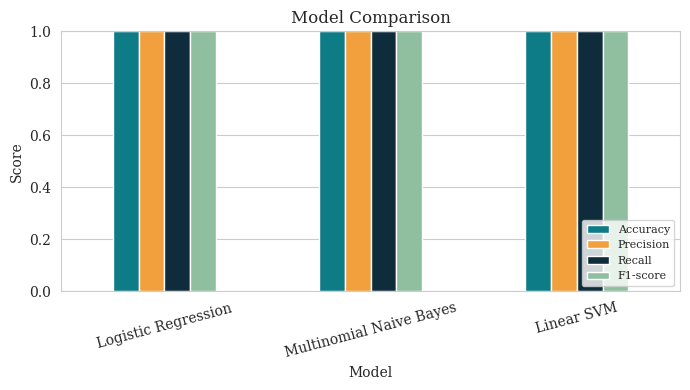

In [11]:
fig, ax = plt.subplots(figsize=(7,4))
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1-score"]].plot.bar(ax=ax, color=['#0E7C86','#F2A03D','#0F2C3D','#8FBF9F'])
plt.title("Model Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

Best model: Logistic Regression

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        72
     neutral       1.00      1.00      1.00        60
    positive       1.00      1.00      1.00       108

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



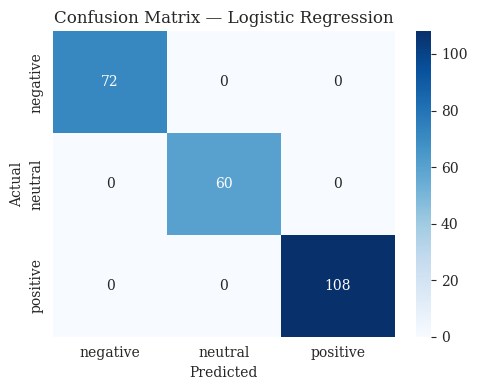

In [12]:
best_name = results_df.iloc[0]["Model"]
best_model = trained[best_name]
preds = best_model.predict(X_test)

print(f"Best model: {best_name}\n")
print(classification_report(y_test, preds, zero_division=0))

cm = confusion_matrix(y_test, preds, labels=best_model.classes_)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.title(f"Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 6. Visualizing sentiment trends

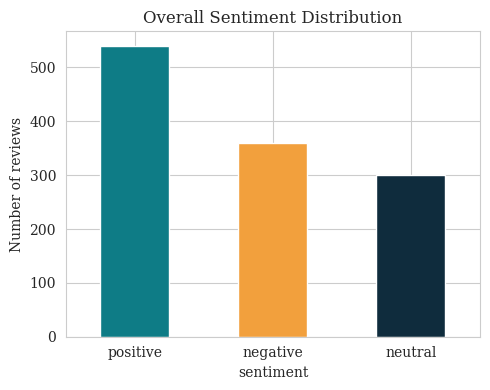

In [13]:
sent_counts = df['sentiment'].value_counts()
plt.figure(figsize=(5,4))
sent_counts.plot.bar(color=['#0E7C86','#F2A03D','#0F2C3D'])
plt.title("Overall Sentiment Distribution")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

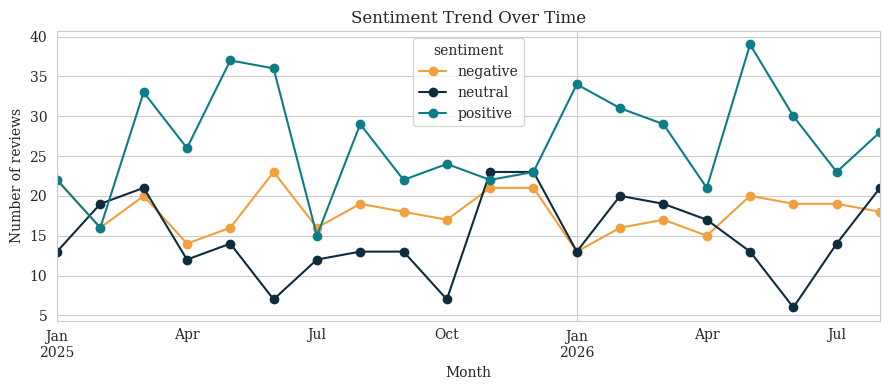

In [14]:
monthly = df.set_index('date').groupby([pd.Grouper(freq='ME'), 'sentiment']).size().unstack(fill_value=0)
monthly.plot(figsize=(9,4), marker='o', color=['#F2A03D','#0F2C3D','#0E7C86'])
plt.title("Sentiment Trend Over Time")
plt.ylabel("Number of reviews")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

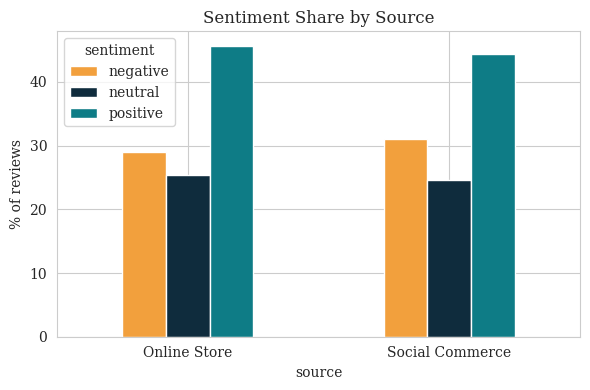

In [15]:
source_sentiment = pd.crosstab(df['source'], df['sentiment'], normalize='index') * 100
source_sentiment.plot.bar(figsize=(6,4), color=['#F2A03D','#0F2C3D','#0E7C86'])
plt.title("Sentiment Share by Source")
plt.ylabel("% of reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Result interpretation (discussion prompts for class)

- Which model performed best on F1-score, and why might that be, given how TF-IDF features behave?
- Look at the confusion matrix: which sentiment class is most often confused with another? Why might that be, given the templates used?
- What does the sentiment trend chart suggest about how opinion is spread across the year?
- Do Flipkart reviews and Twitter posts show different sentiment patterns? What might explain that?

These are exactly the kinds of questions the assignment's **Result Interpretation and Report** section asks students to answer.